# Week 7 - Milestone One week

# 1. Lesson: no lesson this week.  Milestone One is due!

# 2. Weekly graph question

Below are the graphs from last week's weekly graph question.  Suppose you wanted to cause the viewer to examine the last three months of data first.  How could you use preattentive attributes to do that?  Suggest several possibilities.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

/var/folders/v5/yddrf7t17gj_q1nfvqx_2sfm0000gn/T/ipykernel_11132/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

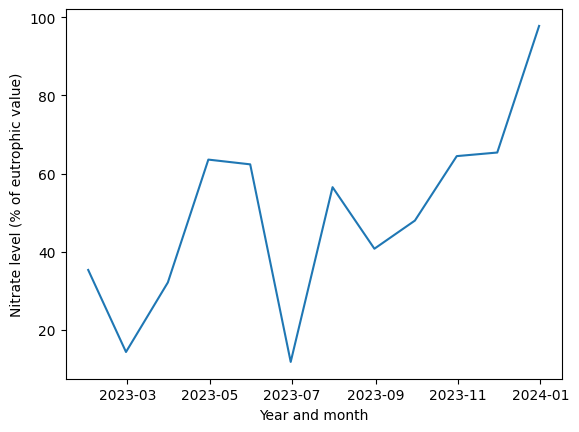

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/var/folders/v5/yddrf7t17gj_q1nfvqx_2sfm0000gn/T/ipykernel_11132/1012779568.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

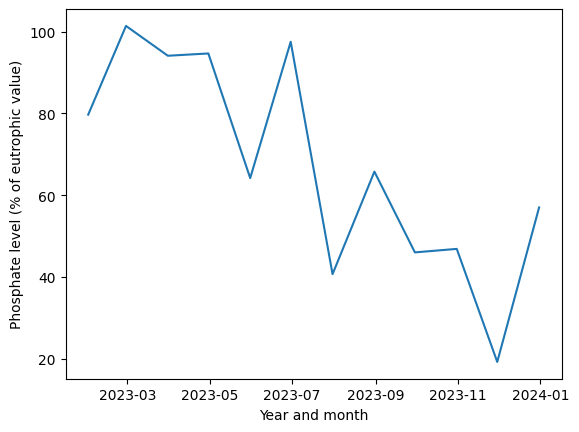

In [4]:
np.random.seed(1)
time_series = 100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

# 3. Working on your datasets

This week, you can work on Milestone One rather than having a particular exercise about working on your datasets

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 99-119 of the Storytelling With Data book as best you can. (The first half of chapter four). You do not have to get the exact data values right, just the overall look and feel.

In [5]:
# create column mapping
column_mapping = {
    'id': 'id',
    'age': 'age',
    'bp': 'blood_pressure',
    'sg': 'specific_gravity',
    'al': 'albumin',
    'su': 'sugar',
    'rbc': 'red_blood_cells',
    'pc': 'pus_cell',
    'pcc': 'pus_cell_clumps',
    'ba': 'bacteria',
    'bgr': 'blood_glucose_random',
    'bu': 'blood_urea',
    'sc': 'serum_creatinine',
    'sod': 'sodium',
    'pot': 'potassium',
    'hemo': 'hemoglobin',
    'pcv': 'packed_cell_volume',
    'wc': 'white_blood_cell_count',
    'rc': 'red_blood_cell_count',
    'htn': 'hypertension',
    'dm': 'diabetes_mellitus',
    'cad': 'coronary_artery_disease',
    'appet': 'appetite',
    'pe': 'pedal_edema',
    'ane': 'anemia',
    'classification': 'classification'
}

# map columns to df
df = pd.read_csv("datasets/kidney_disease.csv")
df.rename(columns=column_mapping, inplace=True)

# verify columns names
print(df.columns)

Index(['id', 'age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'hemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'pedal_edema', 'anemia', 'classification'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       400 non-null    int64  
 1   age                      391 non-null    float64
 2   blood_pressure           388 non-null    float64
 3   specific_gravity         353 non-null    float64
 4   albumin                  354 non-null    float64
 5   sugar                    351 non-null    float64
 6   red_blood_cells          248 non-null    object 
 7   pus_cell                 335 non-null    object 
 8   pus_cell_clumps          396 non-null    object 
 9   bacteria                 396 non-null    object 
 10  blood_glucose_random     356 non-null    float64
 11  blood_urea               381 non-null    float64
 12  serum_creatinine         383 non-null    float64
 13  sodium                   313 non-null    float64
 14  potassium                3

In [7]:
column_null_count = df.isna().sum().to_frame().rename(columns={0: "null_count"})
column_null_count["null_pct"] = df.isnull().sum() / len(df) * 100
column_null_count

,null_count,null_pct
id,0,0.00
age,9,2.25
blood_pressure,12,3.00
specific_gravity,47,11.75
albumin,46,11.50
sugar,49,12.25
red_blood_cells,152,38.00
pus_cell,65,16.25
pus_cell_clumps,4,1.00
bacteria,4,1.00


In [8]:
# select categorical variables
categorical_df = df.select_dtypes(include=['object', 'category'])

print("Unique values for each categorical/object column:")

# Iterate over the selected columns and print their unique values
for col in categorical_df.columns:
    unique_values = df[col].unique()
    print(f"\nColumn '{col}':")
    print(unique_values)

Unique values for each categorical/object column:

Column 'red_blood_cells':
[nan 'normal' 'abnormal']

Column 'pus_cell':
['normal' 'abnormal' nan]

Column 'pus_cell_clumps':
['notpresent' 'present' nan]

Column 'bacteria':
['notpresent' 'present' nan]

Column 'packed_cell_volume':
['44' '38' '31' '32' '35' '39' '36' '33' '29' '28' nan '16' '24' '37' '30'
 '34' '40' '45' '27' '48' '\t?' '52' '14' '22' '18' '42' '17' '46' '23'
 '19' '25' '41' '26' '15' '21' '43' '20' '\t43' '47' '9' '49' '50' '53'
 '51' '54']

Column 'white_blood_cell_count':
['7800' '6000' '7500' '6700' '7300' nan '6900' '9600' '12100' '4500'
 '12200' '11000' '3800' '11400' '5300' '9200' '6200' '8300' '8400' '10300'
 '9800' '9100' '7900' '6400' '8600' '18900' '21600' '4300' '8500' '11300'
 '7200' '7700' '14600' '6300' '\t6200' '7100' '11800' '9400' '5500' '5800'
 '13200' '12500' '5600' '7000' '11900' '10400' '10700' '12700' '6800'
 '6500' '13600' '10200' '9000' '14900' '8200' '15200' '5000' '16300'
 '12400' '\t8400' '

In [9]:
# 1. Strip all leading/trailing whitespace and tabs from all string columns
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# 2. Replace the specific dirty placeholders with actual Nulls
df.replace('\t?', np.nan, inplace=True)

# 3. Targeted cleaning for Specific Columns with tabs/noise
# Fix classification: 'ckd\t' becomes 'ckd'
df['classification'] = df['classification'].replace({'ckd\t': 'ckd'})

# Fix diabetes_mellitus: '\tyes', ' yes', '\tno'
df['diabetes_mellitus'] = df['diabetes_mellitus'].replace({'\tyes': 'yes', '\tno': 'no', ' yes': 'yes'})

# 4. Cast "pseudo-categorical" columns back to Numeric
# These are the ones that should be numbers (PCV, WBC, RC)
numeric_to_fix = ['packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count']

for col in numeric_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Cleaning Complete. Current dtypes:")
print(df[numeric_to_fix + ['classification', 'diabetes_mellitus']].dtypes)

Cleaning Complete. Current dtypes:
packed_cell_volume        float64
white_blood_cell_count    float64
red_blood_cell_count      float64
classification             object
diabetes_mellitus          object
dtype: object


In [10]:
# Iterate over the selected columns and print their unique values
for col in categorical_df.columns:
    unique_values = df[col].unique()
    print(f"\nColumn '{col}':")
    print(unique_values)


Column 'red_blood_cells':
[nan 'normal' 'abnormal']

Column 'pus_cell':
['normal' 'abnormal' nan]

Column 'pus_cell_clumps':
['notpresent' 'present' nan]

Column 'bacteria':
['notpresent' 'present' nan]

Column 'packed_cell_volume':
[44. 38. 31. 32. 35. 39. 36. 33. 29. 28. nan 16. 24. 37. 30. 34. 40. 45.
 27. 48. 52. 14. 22. 18. 42. 17. 46. 23. 19. 25. 41. 26. 15. 21. 43. 20.
 47.  9. 49. 50. 53. 51. 54.]

Column 'white_blood_cell_count':
[ 7800.  6000.  7500.  6700.  7300.    nan  6900.  9600. 12100.  4500.
 12200. 11000.  3800. 11400.  5300.  9200.  6200.  8300.  8400. 10300.
  9800.  9100.  7900.  6400.  8600. 18900. 21600.  4300.  8500. 11300.
  7200.  7700. 14600.  6300.  7100. 11800.  9400.  5500.  5800. 13200.
 12500.  5600.  7000. 11900. 10400. 10700. 12700.  6800.  6500. 13600.
 10200.  9000. 14900.  8200. 15200.  5000. 16300. 12400. 10500.  4200.
  4700. 10900.  8100.  9500.  2200. 12800. 11200. 19100. 12300. 16700.
  2600. 26400.  8800.  7400.  4900.  8000. 12000. 15700.  4

In [11]:
df.describe()

,id,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,hemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'blood_pressure'}>,
        <Axes: title={'center': 'specific_gravity'}>],
       [<Axes: title={'center': 'albumin'}>,
        <Axes: title={'center': 'sugar'}>,
        <Axes: title={'center': 'blood_glucose_random'}>,
        <Axes: title={'center': 'blood_urea'}>],
       [<Axes: title={'center': 'serum_creatinine'}>,
        <Axes: title={'center': 'sodium'}>,
        <Axes: title={'center': 'potassium'}>,
        <Axes: title={'center': 'hemoglobin'}>],
       [<Axes: title={'center': 'packed_cell_volume'}>,
        <Axes: title={'center': 'white_blood_cell_count'}>,
        <Axes: title={'center': 'red_blood_cell_count'}>, <Axes: >]],
      dtype=object)

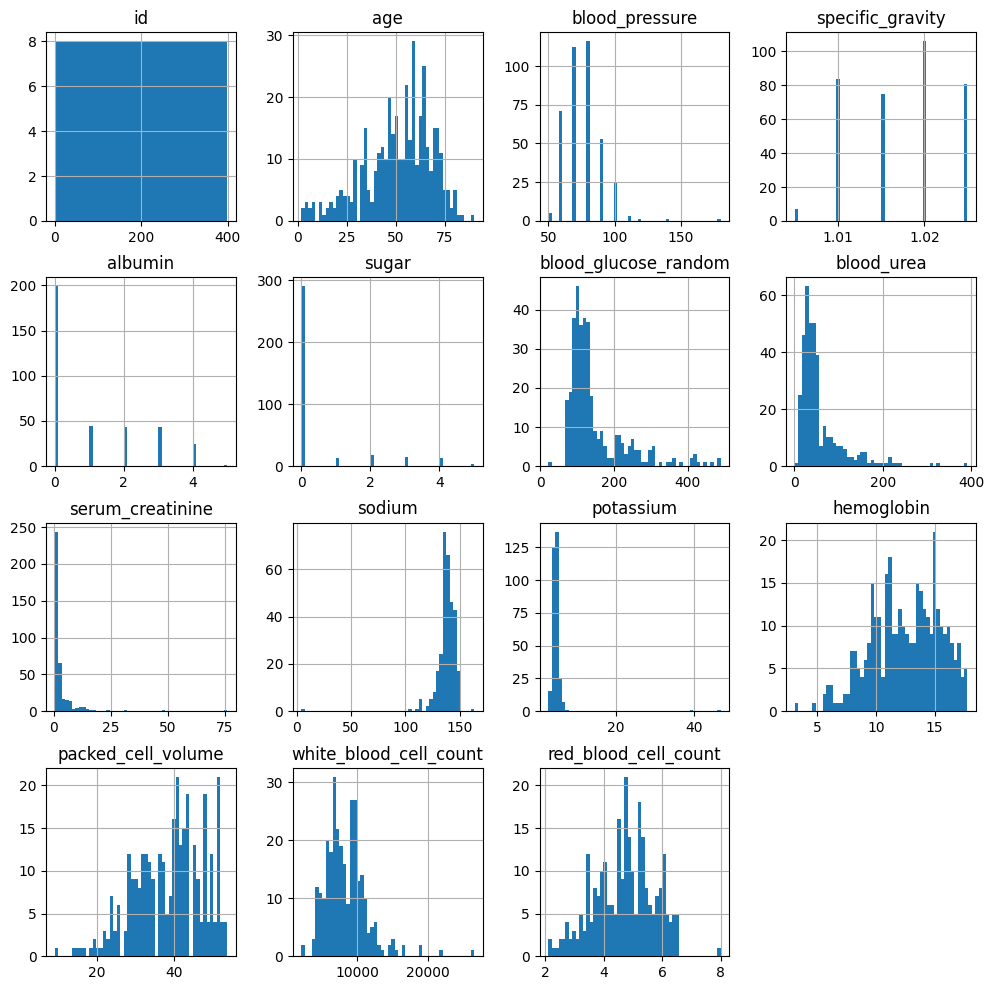

In [12]:
df.hist(figsize=(12,12), bins=50)


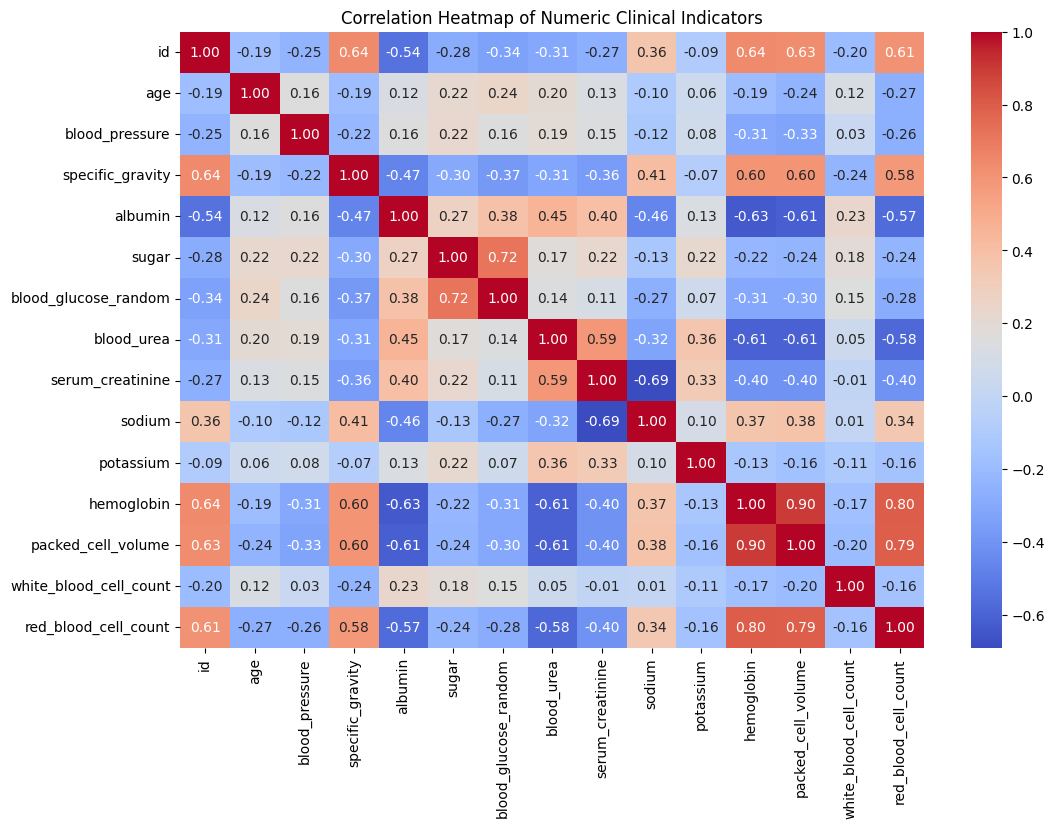

In [13]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Clinical Indicators")
plt.show()

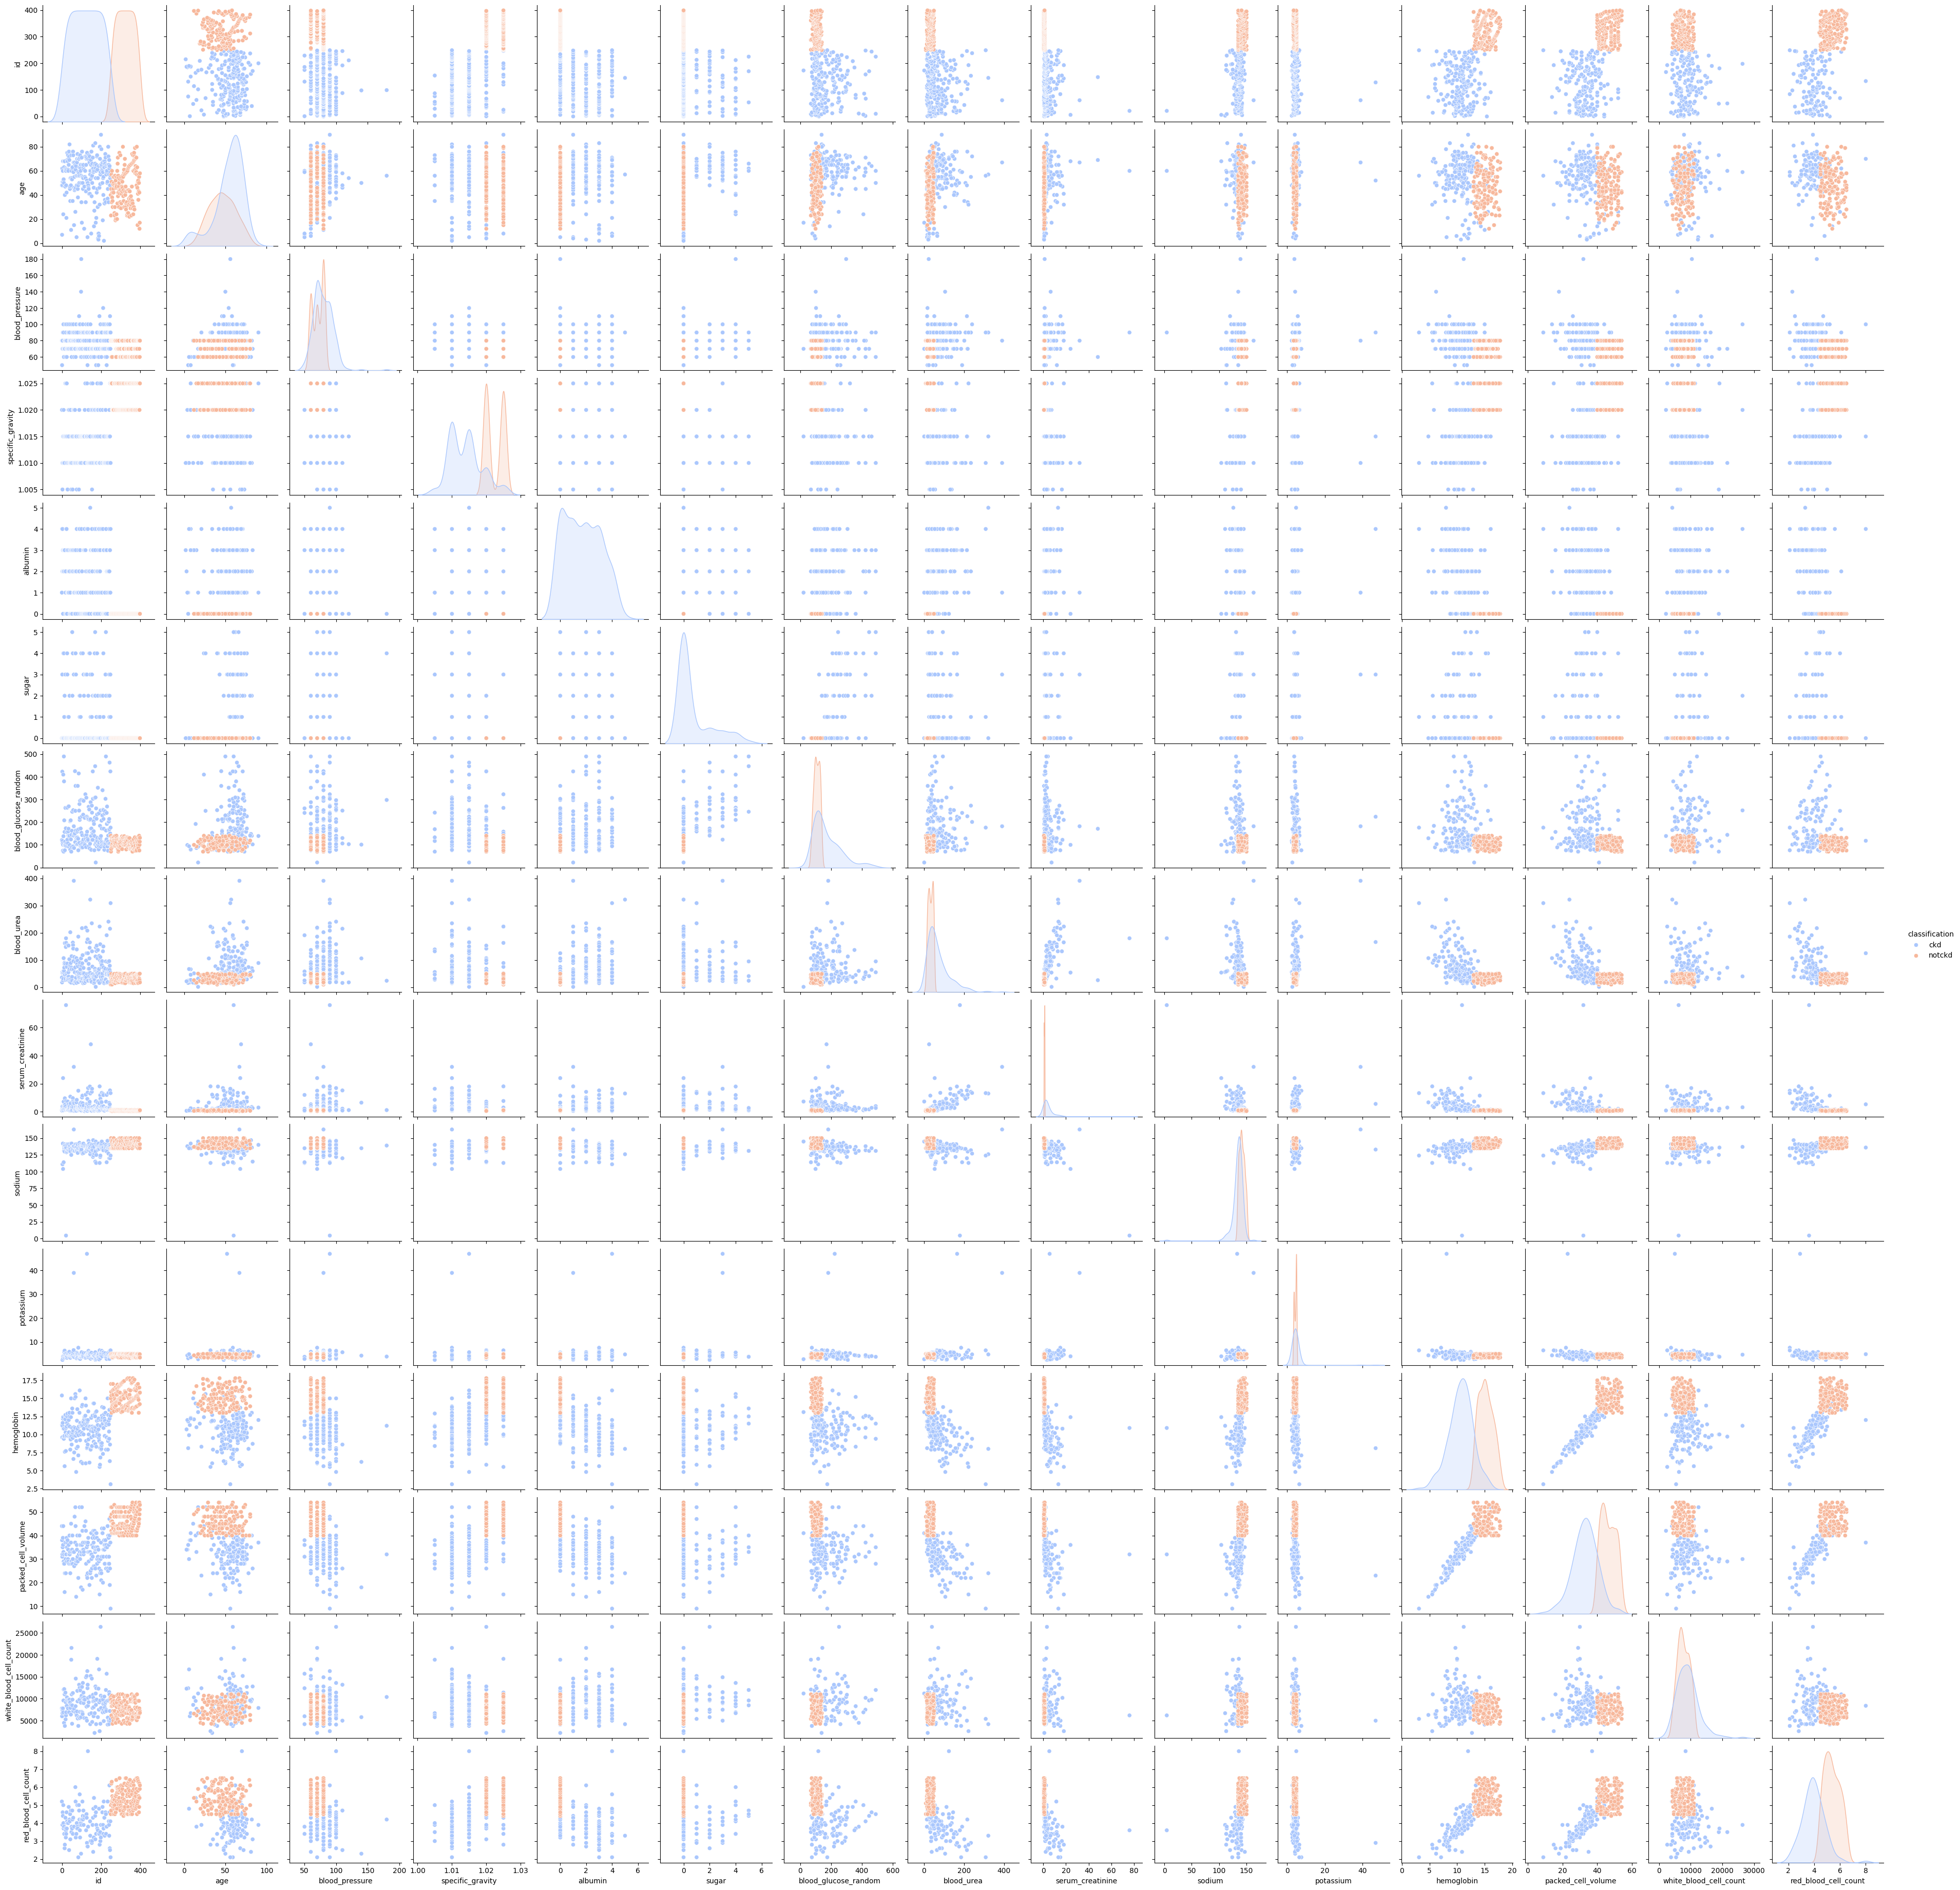

In [14]:
# Select a small subset of highly relevant features
# For example, in your CKD dataset:


sns.pairplot(df, hue='classification', palette='coolwarm', diag_kind='kde')

In [15]:
df.columns

Index(['id', 'age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'hemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'pedal_edema', 'anemia', 'classification'],
      dtype='object')

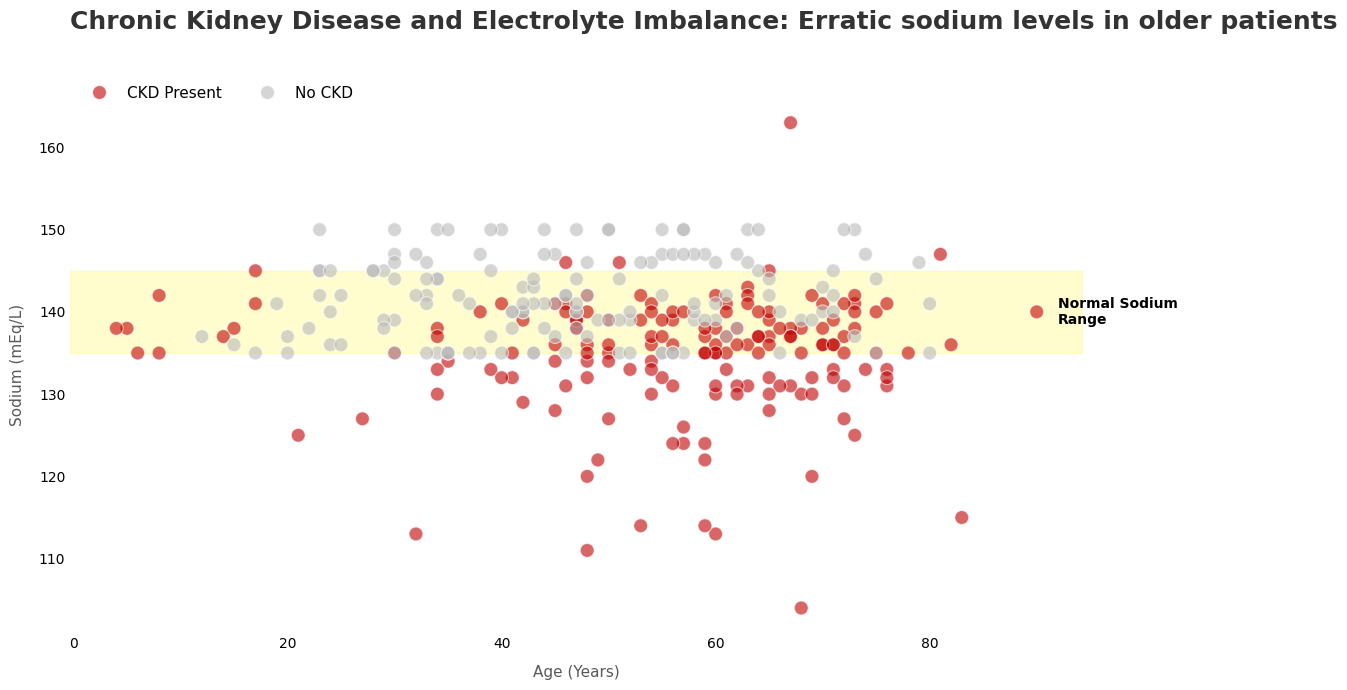

In [16]:
# --- 1. PREPROCESSING: CLEANING, FILTERING & MAPPING ---
# Filtering physiologically impossible outliers (sodium <= 10) [cite: 32, 74]
df_filtered = df[df['sodium'] > 10].copy()

# Strip trailing whitespace/tabs and map to descriptive labels [cite: 51]
df_filtered['class_label'] = df_filtered['classification'].astype(str).str.strip().map({
    'ckd': 'CKD Present', 
    'notckd': 'No CKD'
})

# --- 2. INITIALIZE THE FIGURE ---
fig, ax = plt.subplots(figsize=(12, 7))

# --- 3. CREATE THE PLOT ---
# Scatter plot comparing Sodium and Age against CKD status [cite: 74]
sns.scatterplot(
    data=df_filtered,
    x='age',
    y='sodium',
    hue='class_label',
    palette={'CKD Present': '#c00000', 'No CKD': "#b9b9b9"}, 
    alpha=0.6,
    s=100,
    ax=ax
)

# --- 4. SWD DECLUTTERING ---
sns.despine(left=True, bottom=True)
ax.yaxis.grid(False)
ax.xaxis.grid(False)
ax.tick_params(axis='both', length=0)

# --- 5. ADDING CONTEXT (Normal Range Highlight) ---
# Shading the normal sodium range (135-145 mEq/L) [cite: 31, 32]
plt.axhspan(135, 145, color="#fffa5bff", alpha=0.3, zorder=0)
plt.text(92, 140, 'Normal Sodium\nRange', fontsize=10, color="#000000", va='center', fontweight='bold')

# --- 6. LABELS & THE LEGEND ---
plt.xlabel("Age (Years)", fontsize=11, color='#595959', labelpad=10)
plt.ylabel("Sodium (mEq/L)", fontsize=11, color='#595959', labelpad=10)

# SWD-Style Legend: Clean, no border, placed to avoid data overlap
plt.legend(
    title="", 
    frameon=False, 
    loc='upper left', 
    bbox_to_anchor=(0, 1.05), # Positioned above the chart for quick reference
    ncol=2,
    fontsize=11
)

# --- 7. ACTIVE TITLE ---
# Main takeaway statement as required for 'Exemplary' communication [cite: 71, 77]
plt.title(
    "Chronic Kidney Disease and Electrolyte Imbalance: Erratic sodium levels in older patients", 
    loc='left',
    fontsize=18, 
    fontweight='bold', 
    color='#333333',
    pad=50 
)

plt.tight_layout()
plt.savefig('Figure_7')
plt.show()


/var/folders/v5/yddrf7t17gj_q1nfvqx_2sfm0000gn/T/ipykernel_11132/3686999404.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  line_data = sugar_present_df.groupby(['age_group', 'class_label']).size().reset_index(name='count')


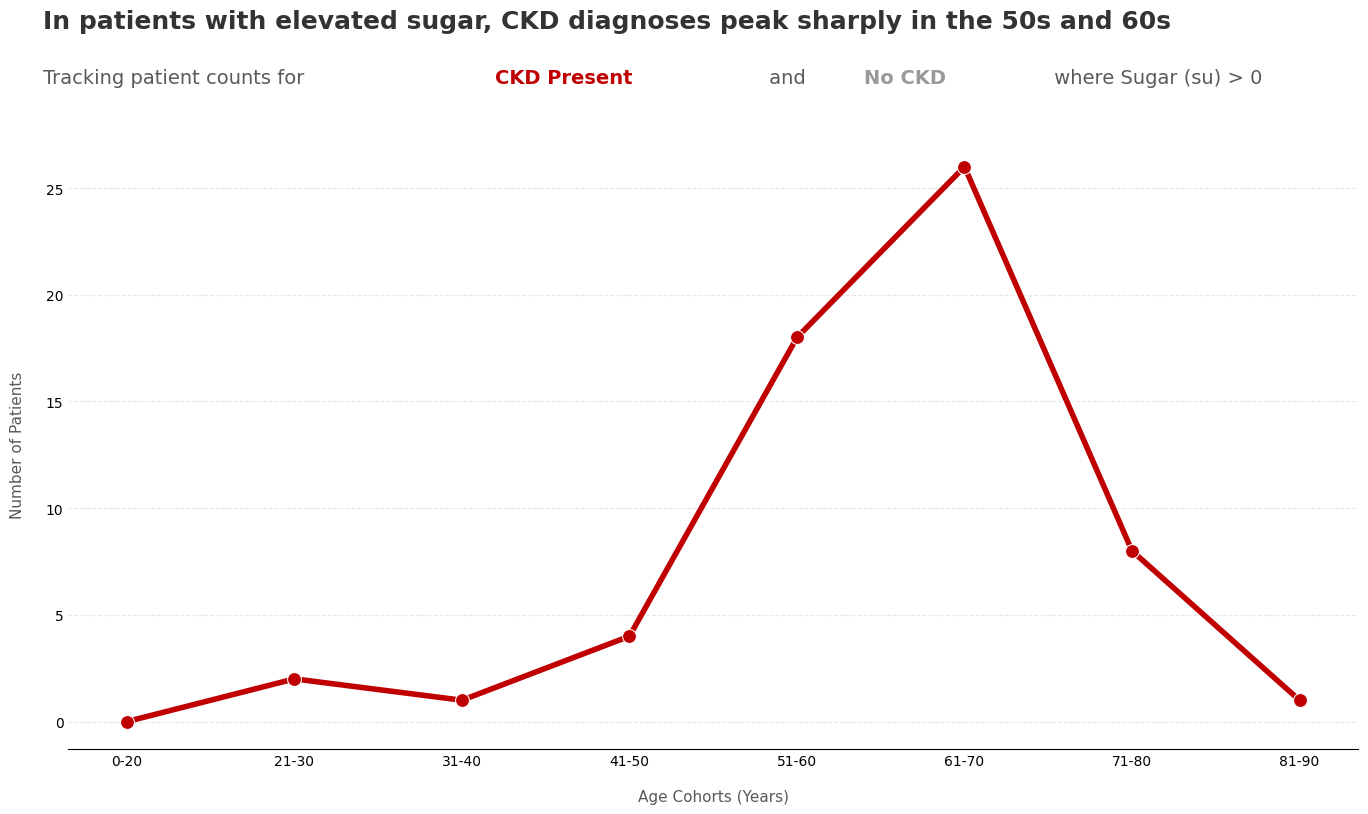

In [17]:
# --- 1. PREPROCESSING: BINNING AGE & FILTERING SUGAR ---
# Ensure age and sugar are numeric
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['sugar'] = pd.to_numeric(df['sugar'], errors='coerce')

# Create 10-year age bins
age_bins = [0, 20, 30, 40, 50, 60, 70, 80, 90]
age_labels = ['0-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# Clean classification labels
df['class_label'] = df['classification'].astype(str).str.strip().map({
    'ckd': 'CKD Present', 
    'notckd': 'No CKD'
})

# Filter for the "Elevated Sugar" group (su > 0) to highlight impact
sugar_present_df = df[df['sugar'] > 0].copy()

# Calculate counts per age group and class
line_data = sugar_present_df.groupby(['age_group', 'class_label']).size().reset_index(name='count')

# --- 2. INITIALIZE THE FIGURE ---
fig, ax = plt.subplots(figsize=(14, 8))

# --- 3. CREATE THE LINE CHART ---
sns.lineplot(
    data=line_data,
    x='age_group',
    y='count',
    hue='class_label',
    palette={'CKD Present': '#c00000', 'No CKD': '#999999'}, # Red for disease, Gray for healthy
    linewidth=4,
    marker='o',
    markersize=10,
    legend=False, # We will use colored text instead
    ax=ax
)

# --- 4. SWD DECLUTTERING ---
sns.despine(left=True, bottom=False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.xaxis.grid(False)
ax.tick_params(axis='both', length=0)

# --- 5. LABELS & TEXT HIERARCHY ---
plt.xlabel("Age Cohorts (Years)", fontsize=11, color='#595959', labelpad=15)
plt.ylabel("Number of Patients", fontsize=11, color='#595959', labelpad=15)

# --- 6. COLORED TEXT AS LEGEND (Active Title & Subtitle) ---
# Title
plt.text(x=-0.5, y=line_data['count'].max() * 1.25, 
         s="In patients with elevated sugar, CKD diagnoses peak sharply in the 50s and 60s", 
         fontsize=18, fontweight='bold', color='#333333', ha='left')

# Subtitle as Legend
plt.text(x=-0.5, y=line_data['count'].max() * 1.15, s="Tracking patient counts for ", fontsize=14, color='#595959', ha='left')
plt.text(x=2.2, y=line_data['count'].max() * 1.15, s="CKD Present", fontsize=14, color='#c00000', fontweight='bold', ha='left')
plt.text(x=3.8, y=line_data['count'].max() * 1.15, s=" and ", fontsize=14, color='#595959', ha='left')
plt.text(x=4.4, y=line_data['count'].max() * 1.15, s="No CKD", fontsize=14, color='#999999', fontweight='bold', ha='left')
plt.text(x=5.5, y=line_data['count'].max() * 1.15, s=" where Sugar (su) > 0", fontsize=14, color='#595959', ha='left')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

/var/folders/v5/yddrf7t17gj_q1nfvqx_2sfm0000gn/T/ipykernel_11132/232176859.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  line_data = df.groupby(['age_group', 'class_label', 'sugar_status']).size().reset_index(name='count')


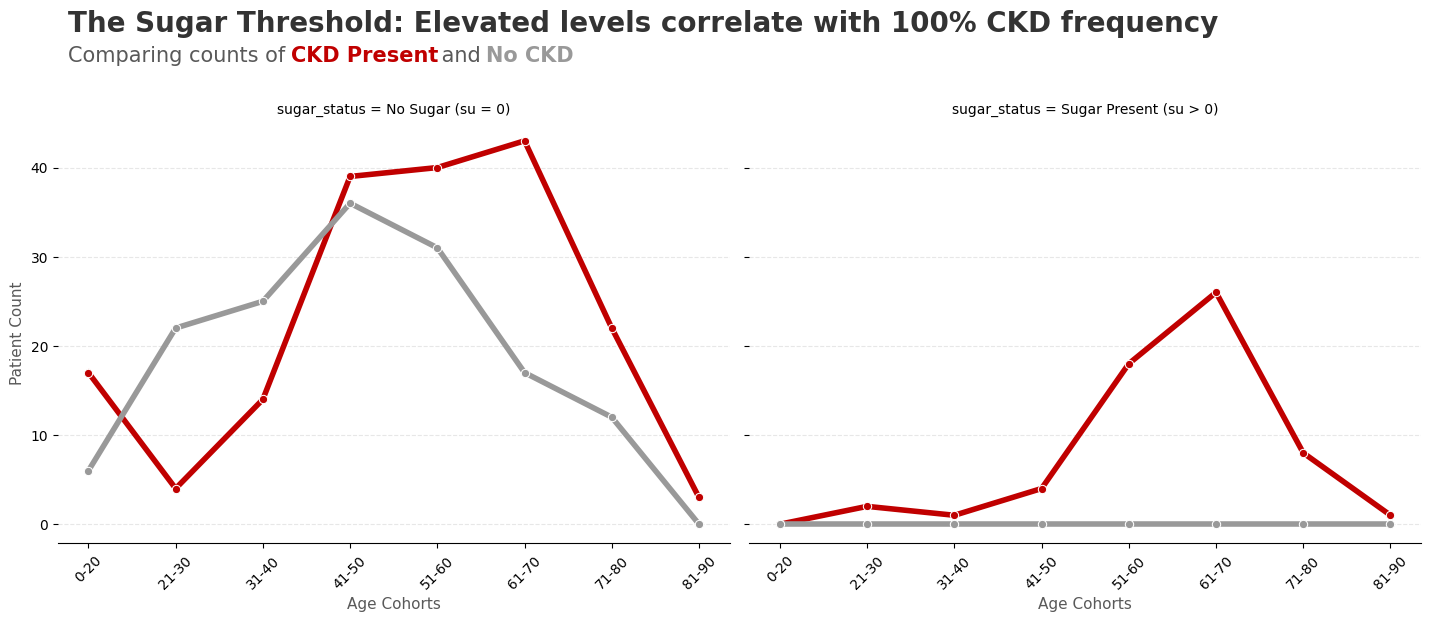

In [18]:
# --- 1. PREPROCESSING: CATEGORIZE SUGAR ---
# Ensure columns are numeric
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['sugar'] = pd.to_numeric(df['sugar'], errors='coerce')

# Create a binary category: No Sugar vs Sugar Present
df['sugar_status'] = df['sugar'].apply(lambda x: 'Sugar Present (su > 0)' if x > 0 else 'No Sugar (su = 0)')

# Create 10-year age bins
age_bins = [0, 20, 30, 40, 50, 60, 70, 80, 90]
age_labels = ['0-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# Clean classification labels
df['class_label'] = df['classification'].astype(str).str.strip().map({'ckd': 'CKD Present', 'notckd': 'No CKD'})

# Calculate counts for the FULL dataset
line_data = df.groupby(['age_group', 'class_label', 'sugar_status']).size().reset_index(name='count')

# --- 2. INITIALIZE FACETED PLOT (Knaflic Style) ---
# We use relplot to create side-by-side comparison panels
g = sns.relplot(
    data=line_data,
    x='age_group',
    y='count',
    hue='class_label',
    col='sugar_status', # This creates the two panels
    kind='line',
    palette={'CKD Present': '#c00000', 'No CKD': '#999999'},
    linewidth=4,
    marker='o',
    height=6,
    aspect=1.2,
    facet_kws={'sharey': True}, 
    legend=False
)

# --- 3. SWD STYLING & DECLUTTERING ---
g.despine(left=True)
for ax in g.axes.flat:
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlabel("Age Cohorts", fontsize=11, color='#595959')
    ax.set_ylabel("Patient Count", fontsize=11, color='#595959')
    ax.tick_params(axis='x', rotation=45)

# --- 4. CUSTOM COLORED TITLES ---
g.figure.subplots_adjust(top=0.8) 

# Main Title: Highlighting the "Missing Line" insight
g.figure.text(x=0.05, y=0.95, s="The Sugar Threshold: Elevated levels correlate with 100% CKD frequency", 
           fontsize=20, fontweight='bold', color='#333333')

# Subtitle as Legend
g.figure.text(x=0.05, y=0.90, s="Comparing counts of ", fontsize=15, color='#595959')
g.figure.text(x=0.205, y=0.90, s="CKD Present", fontsize=15, color='#c00000', fontweight='bold')
g.figure.text(x=0.305, y=0.90, s=" and ", fontsize=15, color='#595959')
g.figure.text(x=0.34, y=0.90, s="No CKD", fontsize=15, color='#999999', fontweight='bold')

plt.savefig('Figure_8')
plt.show()


In [19]:
import os

# Define the output directory and file name
output_dir = "./cleaned_datasets"
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, "cleaned_kidney_disease.csv")

# Save the DataFrame as CSV if it doesn't already exist
if not os.path.exists(output_file):
    df.to_csv(output_file, index=False)
    print(f"DataFrame saved to {output_file}")
else:
    print(f"File already exists at {output_file}")

DataFrame saved to ./cleaned_datasets/cleaned_kidney_disease.csv
